# A题第1-4题计算代码

本 notebook 对应 `第1-4题详细解答.md` 中的主要数值计算和图表生成。代码采用与解答文件一致的成本口径：风光度电成本、分时购电成本、余电上网收益、设备运维和合成氨装置年化投资均计入吨氨成本。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

warnings.filterwarnings('ignore')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 1. 数据录入与参数

In [2]:
load_pu = np.array([
    0.2283, 0.1833, 0.1333, 0.1650, 0.1967, 0.2717,
    0.4167, 0.5617, 0.6683, 0.7000, 0.6867, 0.6500,
    0.5433, 0.4483, 0.6050, 0.6367, 0.6250, 0.5233,
    0.4350, 0.3533, 0.3100, 0.2717, 0.2600, 0.2467,
])

wind_typ = np.array([
    0.2726, 0.3788, 0.3328, 0.3768, 0.4681, 0.2407,
    0.5701, 0.4463, 0.3582, 0.2976, 0.1934, 0.2139,
    0.3630, 0.1677, 0.2794, 0.2527, 0.1596, 0.1607,
    0.1434, 0.0938, 0.0923, 0.1220, 0.0625, 0.0798,
])

pv_typ = np.array([
    0, 0, 0, 0, 0, 0.02, 0.12, 0.28, 0.45, 0.58, 0.67, 0.70,
    0.72, 0.67, 0.58, 0.45, 0.28, 0.08, 0, 0, 0, 0, 0, 0,
])

wind_s = np.array([
    [0.2444, 0.1328, 0.2976, 0.3374, 0.2444, 0.2362],
    [0.2726, 0.2125, 0.3346, 0.3521, 0.3375, 0.2626],
    [0.3788, 0.2345, 0.3567, 0.3273, 0.3848, 0.2947],
    [0.3328, 0.2576, 0.3930, 0.5042, 0.3328, 0.2876],
    [0.3768, 0.2475, 0.3772, 0.4819, 0.3786, 0.2790],
    [0.4681, 0.2405, 0.3369, 0.5770, 0.3579, 0.2741],
    [0.2407, 0.2285, 0.3458, 0.7089, 0.4463, 0.2686],
    [0.5701, 0.1910, 0.3190, 0.6590, 0.2407, 0.2585],
    [0.4463, 0.1187, 0.2678, 0.6269, 0.5581, 0.2418],
    [0.3582, 0.1215, 0.2979, 0.5528, 0.5232, 0.1737],
    [0.2976, 0.1334, 0.2201, 0.2249, 0.3999, 0.1510],
    [0.1934, 0.1073, 0.2325, 0.1913, 0.3582, 0.1515],
    [0.2139, 0.1042, 0.2253, 0.2704, 0.3185, 0.1632],
    [0.3630, 0.1697, 0.2676, 0.2738, 0.3203, 0.1442],
    [0.1677, 0.2091, 0.2651, 0.3788, 0.2064, 0.1358],
    [0.2794, 0.2101, 0.3638, 0.5415, 0.2139, 0.1342],
    [0.2527, 0.1474, 0.3431, 0.4290, 0.3916, 0.1664],
    [0.1596, 0.1652, 0.3087, 0.4153, 0.2093, 0.2102],
    [0.1607, 0.1563, 0.3038, 0.3832, 0.1968, 0.2702],
    [0.1434, 0.1078, 0.2309, 0.2354, 0.2794, 0.2401],
    [0.0938, 0.0582, 0.1807, 0.2202, 0.2471, 0.1708],
    [0.0923, 0.0373, 0.1563, 0.1304, 0.2255, 0.2096],
    [0.1220, 0.0531, 0.1613, 0.1538, 0.1551, 0.1922],
    [0.0798, 0.0924, 0.1993, 0.2116, 0.4232, 0.2418],
])

pv_s = np.array([
    [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0],
    [0, 0, 0, 0], [0, 0, 0, 0], [0.22, 0, 0, 0], [0.40, 0.05, 0.02, 0],
    [0.58, 0.17, 0.05, 0], [0.72, 0.28, 0.08, 0], [0.82, 0.39, 0.12, 0],
    [0.86, 0.49, 0.18, 0.02], [0.88, 0.56, 0.22, 0.08], [0.88, 0.58, 0.22, 0.12],
    [0.82, 0.50, 0.18, 0.08], [0.70, 0.40, 0.11, 0.02], [0.52, 0.30, 0.08, 0],
    [0.38, 0.15, 0.05, 0], [0.18, 0.05, 0.02, 0], [0, 0, 0, 0], [0, 0, 0, 0],
    [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0],
])

HOURS = np.arange(24)
BASE_LOAD = 6 * load_pu
WIND_CAP = 40
PV_CAP = 64
FEED_IN_PRICE = 0.3779
# Power is modeled in MW and hourly energy in MWh; price and O&M data are yuan/kWh.
KWH_PER_MWH = 1000
# Ammonia investment is interpreted as yuan per kgH2 of daily design hydrogen demand.
NH3_INVEST_YUAN_PER_KGH2 = 60000
H2_KG_PER_KG_NH3 = 0.2
KG_PER_TON = 1000
PRODUCTIONS = [72, 63, 54, 45, 36]

tou_price = np.array([
    0.8024 if (10 <= h < 15 or 18 <= h < 21)
    else 0.6074 if (7 <= h < 10 or 15 <= h < 18 or 21 <= h < 23)
    else 0.3424
    for h in HOURS
])

## 2. 通用函数

In [3]:
def split_buy_sell(total_load, wind, pv):
    gen = wind + pv
    buy = np.maximum(total_load - gen, 0)
    sell = np.maximum(gen - total_load, 0)
    return buy, sell, gen


def green_indicators(total_load, gen, buy, sell):
    e_load = total_load.sum()
    e_gen = gen.sum()
    e_buy = buy.sum()
    e_sell = sell.sum()
    self_use = (e_load - e_buy - e_sell) / e_gen
    green_ratio = (e_gen - e_sell) / e_load
    export_ratio = e_sell / e_gen
    return {
        '用电量/MWh': e_load,
        '新能源/MWh': e_gen,
        '购电/MWh': e_buy,
        '上网/MWh': e_sell,
        '自发自用占比': self_use,
        '绿电比例': green_ratio,
        '上网比例': export_ratio,
    }


def classify(ind):
    ok = [ind['自发自用占比'] > 0.6, ind['绿电比例'] > 0.3, ind['上网比例'] < 0.2]
    if all(ok):
        return '全满足'
    if not any(ok):
        return '全不满足'
    return '部分满足'


def daily_cost_72(wind, pv, buy, sell, y, ecap=0, storage_throughput=0):
    """72 t/d 扩容设备成本。y 为 0-1 负荷率数组。"""
    wind_cost = wind.sum() * KWH_PER_MWH * 0.15
    pv_cost = pv.sum() * KWH_PER_MWH * 0.12
    grid_cost = (buy * KWH_PER_MWH * tou_price).sum()
    feed_revenue = sell.sum() * KWH_PER_MWH * FEED_IN_PRICE
    alk_om = (20 * y).sum() * KWH_PER_MWH * 0.1
    pem_om = (20 * y).sum() * KWH_PER_MWH * 0.15
    nh3_om = (1.5 * y).sum() * KWH_PER_MWH * 0.002
    h2_design_kg_per_day = 72 * KG_PER_TON * H2_KG_PER_KG_NH3
    nh3_capex_daily = h2_design_kg_per_day * NH3_INVEST_YUAN_PER_KGH2 / (30 * 365)
    storage_capex_daily = ecap * KWH_PER_MWH * 1000 / (15 * 365)
    storage_om = 0.01 * storage_throughput * KWH_PER_MWH
    return wind_cost + pv_cost + grid_cost - feed_revenue + alk_om + pem_om + nh3_om + nh3_capex_daily + storage_capex_daily + storage_om


def daily_cost_36(wind, pv, buy, sell):
    """36 t/d 初始设备满负荷成本。"""
    return (
        wind.sum() * KWH_PER_MWH * 0.15
        + pv.sum() * KWH_PER_MWH * 0.12
        + (buy * KWH_PER_MWH * tou_price).sum()
        - sell.sum() * KWH_PER_MWH * FEED_IN_PRICE
        + (10 * 24) * KWH_PER_MWH * 0.1
        + (10 * 24) * KWH_PER_MWH * 0.15
        + (0.75 * 24) * KWH_PER_MWH * 0.002
        + (36 * KG_PER_TON * H2_KG_PER_KG_NH3) * NH3_INVEST_YUAN_PER_KGH2 / (30 * 365)
    )


def scenario_power(iw, ip):
    """iw/ip 为 0 基下标。"""
    return WIND_CAP * wind_s[:, iw], PV_CAP * pv_s[:, ip]


def row_from_result(name, production, cost, ind):
    return {
        '场景': name,
        '产量/t': production,
        '吨氨成本/元': cost / production,
        '购电/MWh': ind['购电/MWh'],
        '上网/MWh': ind['上网/MWh'],
        '自发自用占比': ind['自发自用占比'],
        '绿电比例': ind['绿电比例'],
        '上网比例': ind['上网比例'],
        '判定': classify(ind),
    }

## 3. 问题一：典型场景满负荷核算

In [4]:
wind = WIND_CAP * wind_typ
pv = PV_CAP * pv_typ
load_q1 = BASE_LOAD + 20.75
buy, sell, gen = split_buy_sell(load_q1, wind, pv)
ind_q1 = green_indicators(load_q1, gen, buy, sell)
cost_q1 = daily_cost_36(wind, pv, buy, sell)

q1_summary = pd.DataFrame([{
    **ind_q1,
    '风电/MWh': wind.sum(),
    '光伏/MWh': pv.sum(),
    '日净成本/元': cost_q1,
    '吨氨成本/元': cost_q1 / 36,
    '判定': classify(ind_q1),
}])
q1_summary

,用电量/MWh,新能源/MWh,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,风电/MWh,光伏/MWh,日净成本/元,吨氨成本/元,判定
0,558.72,603.448,172.0438,216.7718,0.281556,0.692075,0.359222,245.048,358.4,195056.216695,5418.228242,部分满足


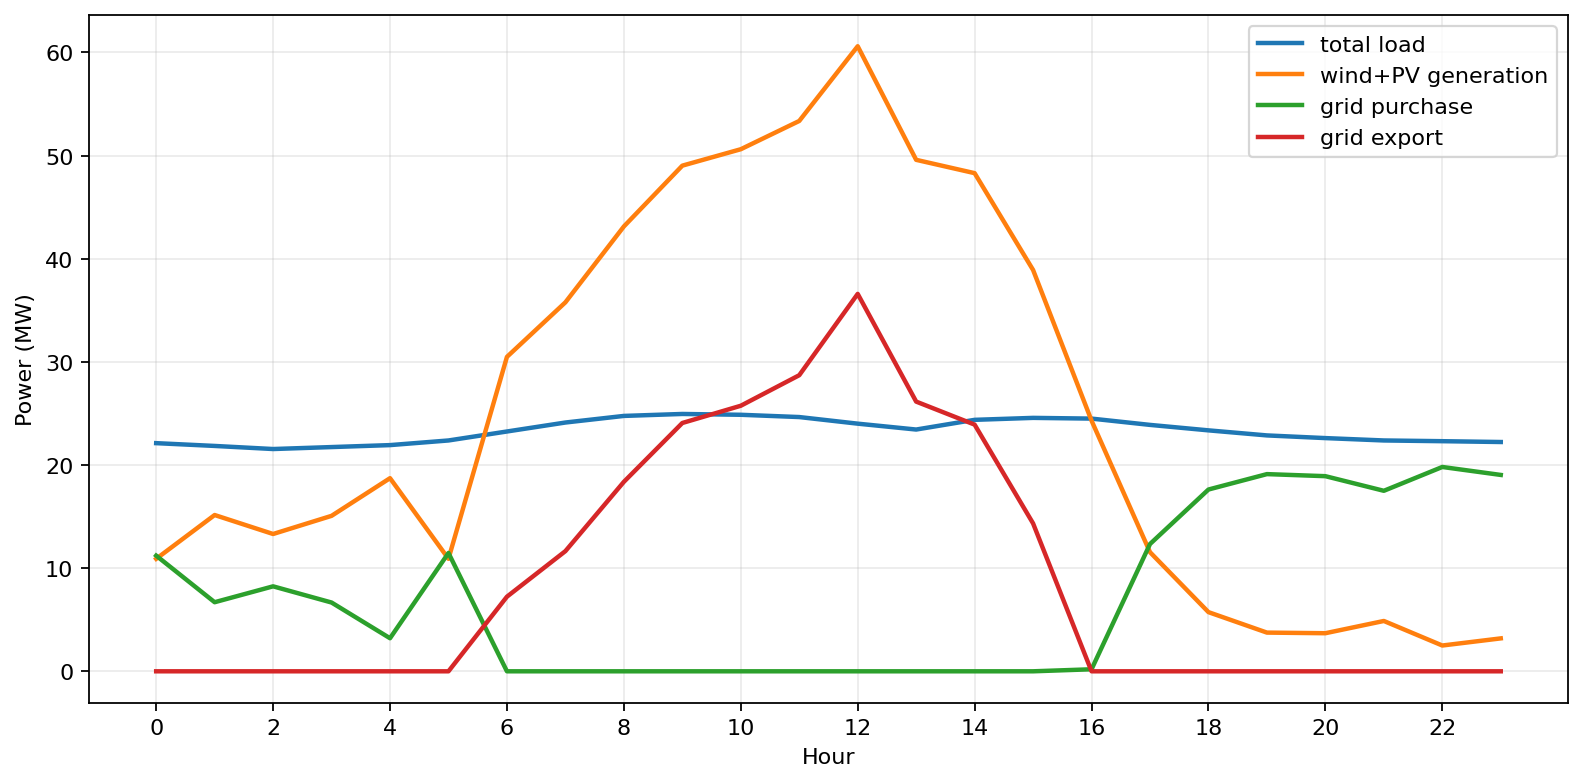

In [5]:
plt.figure(figsize=(10, 5), dpi=160)
plt.plot(HOURS, load_q1, label='total load', linewidth=2)
plt.plot(HOURS, gen, label='wind+PV generation', linewidth=2)
plt.plot(HOURS, buy, label='grid purchase', linewidth=2)
plt.plot(HOURS, sell, label='grid export', linewidth=2)
plt.xticks(HOURS[::2])
plt.xlabel('Hour')
plt.ylabel('Power (MW)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'q1_power_curves.png')
plt.show()

## 4. 问题二：离散开停优化

In [6]:
def opt_discrete(wind, pv, production):
    hours_on = int(production // 3)
    marginal = []
    for h in HOURS:
        re = wind[h] + pv[h]
        base = BASE_LOAD[h]
        c_off = tou_price[h] * max(base - re, 0) - FEED_IN_PRICE * max(re - base, 0)
        c_on = tou_price[h] * max(base + 41.5 - re, 0) - FEED_IN_PRICE * max(re - base - 41.5, 0)
        marginal.append(c_on - c_off)
    y = np.zeros(24)
    y[np.argsort(marginal)[:hours_on]] = 1
    total_load = BASE_LOAD + 41.5 * y
    buy, sell, gen = split_buy_sell(total_load, wind, pv)
    ind = green_indicators(total_load, gen, buy, sell)
    cost = daily_cost_72(wind, pv, buy, sell, y)
    return y, ind, cost


typical_q2_rows = []
for p in PRODUCTIONS:
    y, ind, cost = opt_discrete(WIND_CAP * wind_typ, PV_CAP * pv_typ, p)
    row = row_from_result('typical', p, cost, ind)
    row['开机小时'] = ','.join(map(str, np.where(y > 0)[0]))
    typical_q2_rows.append(row)

typical_q2 = pd.DataFrame(typical_q2_rows)
typical_q2

,场景,产量/t,吨氨成本/元,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,判定,开机小时
0,typical,72,7315.029948,493.9522,40.6802,0.865174,0.532561,0.067413,全满足,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18..."
1,typical,63,6580.506289,376.0424,47.2704,0.843332,0.596616,0.078334,全满足,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,21..."
2,typical,54,6052.459948,264.1404,59.8684,0.801579,0.672980,0.099211,全满足,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,23"
3,typical,45,5697.967631,227.6840,147.9120,0.509777,0.666749,0.245111,部分满足,"0,1,2,3,4,5,6,8,9,10,11,12,13,14,23"
4,typical,36,5383.454730,225.3022,270.0302,0.105042,0.596753,0.447479,部分满足,"0,1,2,3,4,5,6,9,11,12,14,23"


In [7]:
def solve_all_scenarios_discrete():
    rows = []
    detail = {}
    for iw in range(6):
        for ip in range(4):
            wind, pv = scenario_power(iw, ip)
            candidates = []
            for p in PRODUCTIONS:
                y, ind, cost = opt_discrete(wind, pv, p)
                candidates.append((p, y, ind, cost))
            best = min(candidates, key=lambda x: x[3] / x[0])
            name = f'W{iw+1}P{ip+1}'
            rows.append(row_from_result(name, best[0], best[3], best[2]))
            detail[name] = candidates
    return pd.DataFrame(rows), detail


q2_df, q2_detail = solve_all_scenarios_discrete()
q2_df

,场景,产量/t,吨氨成本/元,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,判定
0,W1P1,36,4247.561664,233.2102,436.2542,-0.145379,0.582599,0.572689,部分满足
1,W1P2,36,6219.066080,262.5022,206.9862,0.177327,0.530172,0.411337,部分满足
2,W1P3,36,7902.034827,345.8904,124.6144,0.261422,0.380924,0.369289,部分满足
3,W1P4,36,8463.028605,361.2504,75.3344,0.447703,0.353432,0.276148,部分满足
4,W2P1,36,4870.111022,263.2564,363.4404,-0.103166,0.528822,0.551583,部分满足
5,W2P2,36,6896.216080,298.4522,140.0762,0.300221,0.465829,0.349890,部分满足
6,W2P3,36,8754.478161,411.9984,87.8624,0.250909,0.262603,0.374546,全不满足
7,W2P4,36,9316.939464,427.5886,38.8126,0.543231,0.234700,0.228385,全不满足
8,W3P1,36,4136.546708,223.3262,445.4462,-0.140941,0.600290,0.570471,部分满足
9,W3P2,36,6037.690400,245.1004,208.6604,0.200963,0.561318,0.399518,部分满足


In [8]:
q2_class = q2_df['判定'].value_counts().rename_axis('分类').reset_index(name='场景数')
q2_class['天数'] = q2_class['场景数'] * 15
q2_class['占比'] = q2_class['场景数'] / 24
annual_cost_q2 = (q2_df['吨氨成本/元'] * q2_df['产量/t'] * 15).sum() / (q2_df['产量/t'] * 15).sum()
annual_prod_q2 = (q2_df['产量/t'] * 15).sum()
q2_class, annual_prod_q2, annual_cost_q2

(     分类  场景数   天数     占比
 0  部分满足   21  315  0.875
 1  全不满足    3   45  0.125,
 12960,
 6685.603434649289)

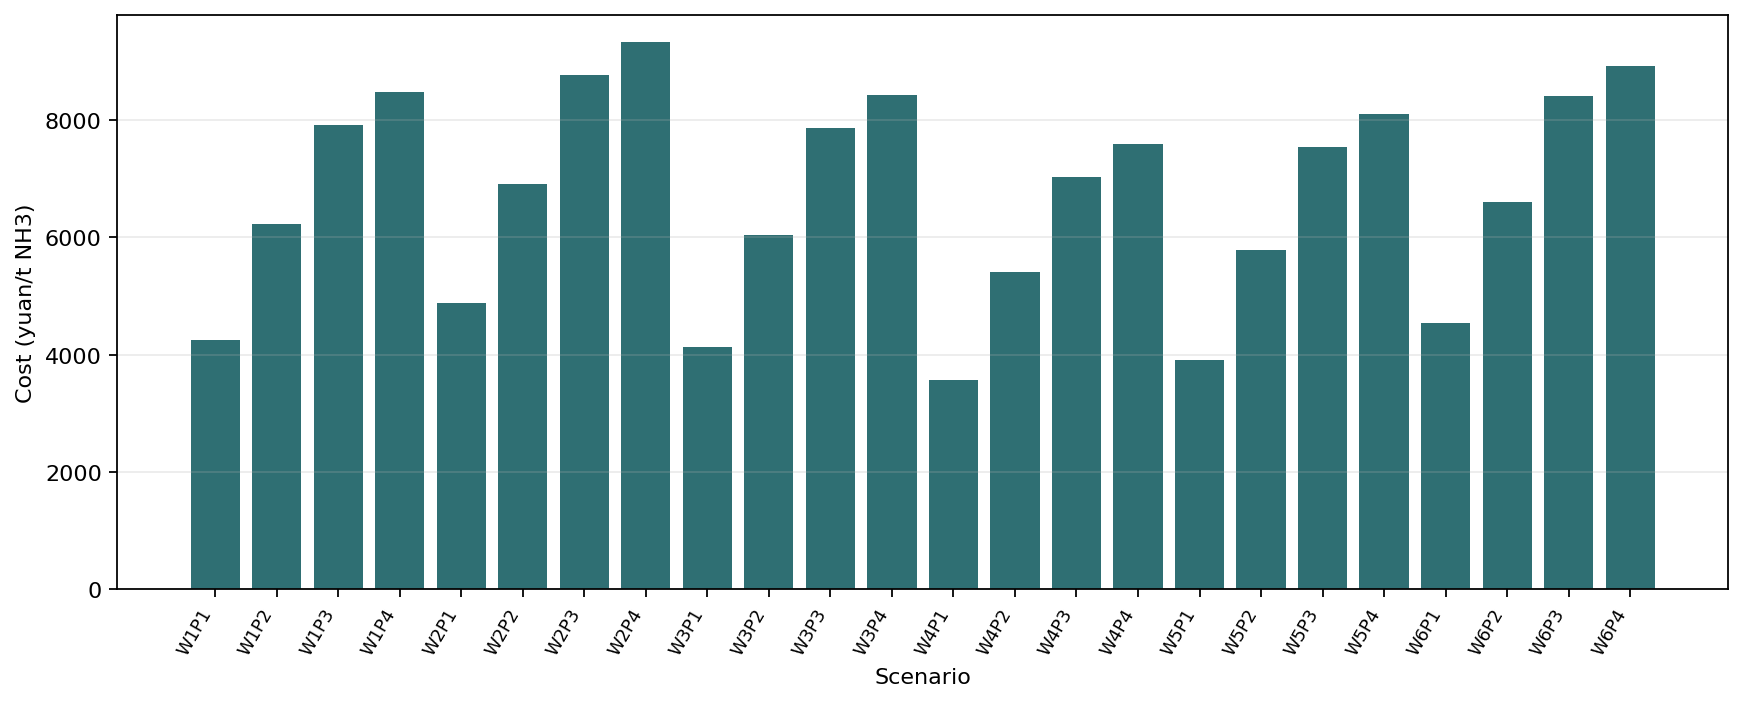

In [9]:
plt.figure(figsize=(11, 4.5), dpi=160)
plt.bar(np.arange(len(q2_df)), q2_df['吨氨成本/元'], color='#2f6f73')
plt.xticks(np.arange(len(q2_df)), q2_df['场景'], rotation=60, ha='right', fontsize=8)
plt.ylabel('Cost (yuan/t NH3)')
plt.xlabel('Scenario')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / 'q2_q3_cost_distribution.png')
plt.show()

## 5. 问题三：连续调节优化

因为谷电价低于上网电价，不能把购电和售电同时作为自由线性变量，否则会出现数学套利。这里用逐小时分段成本和步长 0.01 的动态规划求解。

In [10]:
def opt_continuous_dp(wind, pv, production, step=0.01):
    vals = np.arange(10, 101)  # y * 100, i.e. 0.10 to 1.00
    target = int(round(production / 3 * 100))
    inf = 1e15
    dp = np.full(target + 1, inf)
    dp[0] = 0
    prev = np.full((24, target + 1), -1, dtype=np.int16)

    for h in HOURS:
        new = np.full(target + 1, inf)
        choice = np.full(target + 1, -1, dtype=np.int16)
        re = wind[h] + pv[h]
        base = BASE_LOAD[h]
        costs = []
        for v in vals:
            y = v / 100
            demand = base + 41.5 * y
            costs.append(
                KWH_PER_MWH * (
                    tou_price[h] * max(demand - re, 0)
                    - FEED_IN_PRICE * max(re - demand, 0)
                    + (20 * y) * 0.1
                    + (20 * y) * 0.15
                    + (1.5 * y) * 0.002
                )
            )
        for v, c in zip(vals, costs):
            cand = dp[: target + 1 - v] + c
            better = cand < new[v:]
            idx = np.where(better)[0] + v
            new[idx] = cand[better]
            choice[idx] = v
        dp = new
        prev[h] = choice

    y_list = []
    s = target
    for h in range(23, -1, -1):
        v = prev[h, s]
        if v < 0:
            raise RuntimeError('No feasible DP solution')
        y_list.append(v / 100)
        s -= int(v)
    y = np.array(y_list[::-1])
    total_load = BASE_LOAD + 41.5 * y
    buy, sell, gen = split_buy_sell(total_load, wind, pv)
    ind = green_indicators(total_load, gen, buy, sell)
    cost = daily_cost_72(wind, pv, buy, sell, y)
    return y, ind, cost


typical_q3_rows = []
for p in PRODUCTIONS:
    y, ind, cost = opt_continuous_dp(WIND_CAP * wind_typ, PV_CAP * pv_typ, p)
    typical_q3_rows.append(row_from_result('typical', p, cost, ind))

typical_q3 = pd.DataFrame(typical_q3_rows)
typical_q3

,场景,产量/t,吨氨成本/元,购电/MWh,上网/MWh,自发自用占比,绿电比例,上网比例,判定
0,typical,72,7315.029948,493.9522,40.6802,0.865174,0.532561,0.067413,全满足
1,typical,63,6574.636608,369.4522,40.6802,0.865174,0.603686,0.067413,全满足
2,typical,54,5992.070487,244.9522,40.6802,0.865174,0.696736,0.067413,全满足
3,typical,45,5762.059918,235.2722,155.5002,0.484628,0.655642,0.257686,部分满足
4,typical,36,5478.754064,235.2722,280.0002,0.071999,0.578909,0.464001,部分满足


In [11]:
def solve_all_scenarios_continuous():
    rows = []
    detail = {}
    for iw in range(6):
        for ip in range(4):
            wind, pv = scenario_power(iw, ip)
            candidates = []
            for p in PRODUCTIONS:
                y, ind, cost = opt_continuous_dp(wind, pv, p)
                candidates.append((p, y, ind, cost))
            best = min(candidates, key=lambda x: x[3] / x[0])
            name = f'W{iw+1}P{ip+1}'
            rows.append(row_from_result(name, best[0], best[3], best[2]))
            detail[name] = candidates
    return pd.DataFrame(rows), detail


q3_df, q3_detail = solve_all_scenarios_continuous()
annual_cost_q3 = (q3_df['吨氨成本/元'] * q3_df['产量/t'] * 15).sum() / (q3_df['产量/t'] * 15).sum()
q3_df, annual_cost_q3

(      场景  产量/t       吨氨成本/元    购电/MWh    上网/MWh    自发自用占比      绿电比例      上网比例    判定
 0   W1P1    36  4299.085164  238.9202  441.9642 -0.160370  0.572379  0.580185  部分满足
 1   W1P2    36  6137.495830  253.0002  197.4842  0.215093  0.547179  0.392454  部分满足
 2   W1P3    36  7324.982052  253.0002   31.7242  0.811974  0.547179  0.094013   全满足
 3   W1P4    36  8001.955855  286.0984    0.1824  0.998663  0.487940  0.000669   全满足
 4   W2P1    36  4985.930664  276.6322  376.8162 -0.143767  0.504882  0.571883  部分满足
 5   W2P2    36  6824.341330  290.7122  132.3362  0.338888  0.479682  0.330556  部分满足
 6   W2P3    36  8228.227527  324.4340    0.2980  0.997459  0.419326  0.001270   全满足
 7   W2P4    36  9134.774497  388.9342    0.1582  0.998138  0.303884  0.000931   全满足
 8   W3P1    36  4136.546708  223.3262  445.4462 -0.140941  0.600290  0.570471  部分满足
 9   W3P2    36  5974.957375  237.4062  200.9662  0.230427  0.575089  0.384786  部分满足
 10  W3P3    36  7162.443597  237.4062   35.2062  0.802501  0.575

## 6. 问题四：离网和储能

In [12]:
def offgrid_no_storage(wind, pv):
    gen = wind + pv
    residual = gen - BASE_LOAD
    y = np.clip(residual / 41.5, 0, 1)
    curt = np.maximum(residual - 41.5 * y, 0).sum()
    base_deficit = np.maximum(-residual, 0).sum()
    production = 3 * y.sum()
    cost = (
        wind.sum() * KWH_PER_MWH * 0.15
        + pv.sum() * KWH_PER_MWH * 0.12
        + (20 * y).sum() * KWH_PER_MWH * 0.1
        + (20 * y).sum() * KWH_PER_MWH * 0.15
        + (1.5 * y).sum() * KWH_PER_MWH * 0.002
        + (72 * KG_PER_TON * H2_KG_PER_KG_NH3) * NH3_INVEST_YUAN_PER_KGH2 / (30 * 365)
    )
    return y, production, cost, curt, base_deficit


off_rows = []
off_detail = {}
for iw in range(6):
    for ip in range(4):
        wind, pv = scenario_power(iw, ip)
        y, production, cost, curt, deficit = offgrid_no_storage(wind, pv)
        name = f'W{iw+1}P{ip+1}'
        off_rows.append({
            '场景': name,
            '产量/t': production,
            '吨氨成本/元': cost / production,
            '弃电/MWh': curt,
            '常规负荷缺供/MWh': deficit,
        })
        off_detail[name] = (y, production, cost, curt, deficit)

off_df = pd.DataFrame(off_rows)
off_annual_prod = (off_df['产量/t'] * 15).sum()
off_annual_cost = (off_df['吨氨成本/元'] * off_df['产量/t'] * 15).sum() / off_annual_prod
off_df, off_annual_prod, off_annual_cost

(      场景       产量/t        吨氨成本/元        弃电/MWh  常规负荷缺供/MWh
 0   W1P1  40.895422   6017.432539  1.353240e+02      0.0000
 1   W1P2  31.448227   6337.510594  7.450200e+00      0.0000
 2   W1P3  20.004145   8014.706856  5.329071e-15      0.0000
 3   W1P4  15.331373   9443.245915  2.664535e-15      0.0000
 4   W2P1  36.774231   6085.339144  8.961200e+01      0.1382
 5   W2P2  24.561123   7018.778266  2.220446e-15      0.1382
 6   W2P3  12.578472  10535.047937  2.220446e-15      0.1382
 7   W2P4   7.905701  14795.067627  2.220446e-15      0.1382
 8   W3P1  42.921817   5878.739794  1.263682e+02      0.0000
 9   W3P2  33.096405   6191.412083  3.726400e+00      0.0000
 10  W3P3  21.383133   7739.205035  8.881784e-16      0.0000
 11  W3P4  16.710361   8972.817425  8.881784e-16      0.0000
 12  W4P1  46.445639   5869.557644  1.737060e+02      0.0000
 13  W4P2  39.607504   5811.636738  9.740200e+00      0.0000
 14  W4P3  28.328964   6759.314576  9.325873e-15      0.0000
 15  W4P4  23.656193   7

In [13]:
scale_need = []
for iw in range(6):
    for ip in range(4):
        wind, pv = scenario_power(iw, ip)
        re = wind + pv
        scale_need.extend(((BASE_LOAD + 41.5) / np.maximum(re, 1e-9)).tolist())

k_min = max(scale_need)
k_min, WIND_CAP * k_min, PV_CAP * k_min

(28.907640750670243, 1156.3056300268097, 1850.0890080428956)

In [14]:
ETA_C = 0.9
ETA_D = 0.9
LOSS = 0.002


def dispatch_storage_offgrid(wind, pv, ecap):
    n = 24
    gen = wind + pv
    # Variables: y, charge, discharge, soc, curtail, unserved_base.
    m = 6 * n
    c = np.zeros(m)
    c[:n] = -3
    c[5 * n:] = 10000

    aeq = []
    beq = []
    for h in range(n):
        row = np.zeros(m)
        row[h] = -41.5
        row[n + h] = -1
        row[2 * n + h] = 1
        row[4 * n + h] = -1
        row[5 * n + h] = 1
        aeq.append(row)
        beq.append(BASE_LOAD[h] - gen[h])

    for h in range(n):
        row = np.zeros(m)
        row[3 * n + h] = 1
        row[3 * n + (h - 1) % n] = -(1 - LOSS)
        row[n + h] = -ETA_C
        row[2 * n + h] = 1 / ETA_D
        aeq.append(row)
        beq.append(0)

    bounds = [(0, 1)] * n + [(0, None)] * n + [(0, None)] * n + [(0, ecap)] * n + [(0, None)] * n + [(0, None)] * n
    res = linprog(c, A_eq=np.array(aeq), b_eq=np.array(beq), bounds=bounds, method='highs')
    if not res.success:
        raise RuntimeError(res.message)

    x = res.x
    y = x[:n]
    charge = x[n:2 * n]
    discharge = x[2 * n:3 * n]
    soc = x[3 * n:4 * n]
    curtail = x[4 * n:5 * n]
    unserved = x[5 * n:6 * n]
    production = 3 * y.sum()
    throughput = charge.sum() + discharge.sum()
    cost = daily_cost_72(wind, pv, np.zeros(n), np.zeros(n), y, ecap=ecap, storage_throughput=throughput)
    return y, charge, discharge, soc, curtail, unserved, production, cost, throughput


max_curt_scenario = off_df.sort_values('弃电/MWh', ascending=False).iloc[0]['场景']
iw = int(max_curt_scenario[1]) - 1
ip = int(max_curt_scenario[3]) - 1
wind_max_curt, pv_max_curt = scenario_power(iw, ip)

storage_scan = []
for ecap in np.arange(0, 301, 1):
    out = dispatch_storage_offgrid(wind_max_curt, pv_max_curt, ecap)
    production = out[6]
    cost = out[7]
    curtail = out[4].sum()
    storage_scan.append({'储能/MWh': ecap, '产量/t': production, '吨氨成本/元': cost / production, '弃电/MWh': curtail})

storage_scan_df = pd.DataFrame(storage_scan)
best_storage = storage_scan_df.loc[storage_scan_df['吨氨成本/元'].idxmin()]
best_storage

储能/MWh     155.000000
产量/t        56.450642
吨氨成本/元    5681.635109
弃电/MWh       0.000000
Name: 155, dtype: float64

In [15]:
ecap_best = float(best_storage['储能/MWh'])
storage_rows = []
for iw in range(6):
    for ip in range(4):
        wind, pv = scenario_power(iw, ip)
        out = dispatch_storage_offgrid(wind, pv, ecap_best)
        production = out[6]
        cost = out[7]
        curtail = out[4].sum()
        storage_rows.append({
            '场景': f'W{iw+1}P{ip+1}',
            '产量/t': production,
            '吨氨成本/元': cost / production,
            '弃电/MWh': curtail,
        })

storage_df = pd.DataFrame(storage_rows)
storage_annual_prod = (storage_df['产量/t'] * 15).sum()
storage_annual_cost = (storage_df['吨氨成本/元'] * storage_df['产量/t'] * 15).sum() / storage_annual_prod
storage_df, storage_annual_prod, storage_annual_cost

(      场景       产量/t        吨氨成本/元  弃电/MWh
 0   W1P1  48.705707   5951.141550     0.0
 1   W1P2  31.883595   7165.903039     0.0
 2   W1P3  20.004145   9429.938693     0.0
 3   W1P4  15.331373  11289.819041     0.0
 4   W2P1  41.951075   6253.500095     0.0
 5   W2P2  24.548764   8174.833418     0.0
 6   W2P3  12.566114  12796.939071     0.0
 7   W2P4   7.893343  18402.643006     0.0
 8   W3P1  50.219048   5875.841729     0.0
 9   W3P2  33.314084   7013.681561     0.0
 10  W3P3  21.383133   9063.169250     0.0
 11  W3P4  16.710361  10667.005931     0.0
 12  W4P1  56.450642   5681.635109     0.0
 13  W4P2  40.174886   6462.171875     0.0
 14  W4P3  28.328964   7758.662891     0.0
 15  W4P4  23.656193   8633.910705     0.0
 16  W5P1  52.521968   5812.519620     0.0
 17  W5P2  36.017291   6776.191080     0.0
 18  W5P3  24.172048   8449.301825     0.0
 19  W5P4  19.499277   9676.641102     0.0
 20  W6P1  46.038482   6032.063270     0.0
 21  W6P2  28.661205   7538.606599     0.0
 22  W6P3  

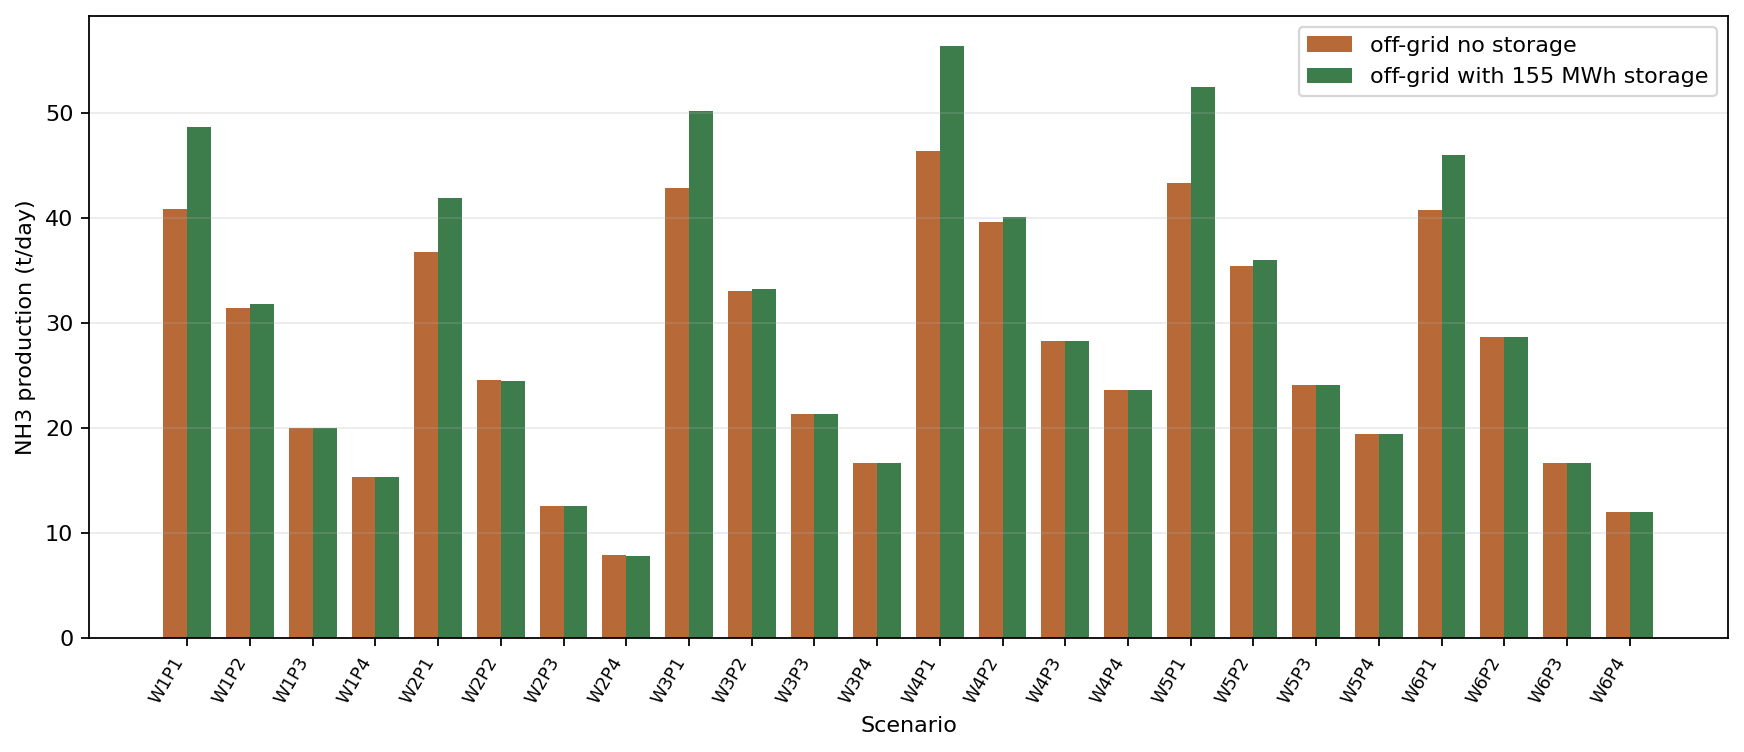

In [16]:
plot_df = off_df[['场景', '产量/t']].rename(columns={'产量/t': '无储能'})
plot_df['有储能'] = storage_df['产量/t']

x = np.arange(len(plot_df))
w = 0.38
plt.figure(figsize=(11, 4.8), dpi=160)
plt.bar(x - w / 2, plot_df['无储能'], width=w, label='off-grid no storage', color='#b86938')
plt.bar(x + w / 2, plot_df['有储能'], width=w, label=f'off-grid with {ecap_best:.0f} MWh storage', color='#3c7d4b')
plt.xticks(x, plot_df['场景'], rotation=60, ha='right', fontsize=8)
plt.ylabel('NH3 production (t/day)')
plt.xlabel('Scenario')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'q4_production_compare.png')
plt.show()

## 7. 汇总

In [17]:
summary = pd.DataFrame([
    {'模式': '并网-问题二离散', '年产量/t': annual_prod_q2, '平均吨氨成本/元': annual_cost_q2, '产能利用率': annual_prod_q2 / (72 * 360)},
    {'模式': '并网-问题三连续', '年产量/t': (q3_df['产量/t'] * 15).sum(), '平均吨氨成本/元': annual_cost_q3, '产能利用率': (q3_df['产量/t'] * 15).sum() / (72 * 360)},
    {'模式': '离网-无储能', '年产量/t': off_annual_prod, '平均吨氨成本/元': off_annual_cost, '产能利用率': off_annual_prod / (72 * 360)},
    {'模式': f'离网-{ecap_best:.0f}MWh储能', '年产量/t': storage_annual_prod, '平均吨氨成本/元': storage_annual_cost, '产能利用率': storage_annual_prod / (72 * 360)},
])
summary

,模式,年产量/t,平均吨氨成本/元,产能利用率
0,并网-问题二离散,12960.000000,6685.603435,0.500000
1,并网-问题三连续,12960.000000,6402.150579,0.500000
2,离网-无储能,9934.083976,6879.034275,0.383259
3,离网-155MWh储能,10630.740538,7516.679614,0.410137
